#  WHACS vs CORA vs Buoy Comparison



In [1]:
from sklearn.metrics import mean_squared_error
# Load and display the verification results
import pandas as pd
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import glob

## Comparison Buoys

In [2]:
buoys = {
    "44088": (-74.8390, 36.6120),
    "44100": (-75.5930, 36.2580),
    "44086": (-75.4210, 36.0010),
    "44056": (-75.7140, 36.2000),
    "44019": (-75.2000, 36.4000),
    "44095": (-75.3300, 35.7500),
    "41120": (-75.2850, 35.2580),
    "41025": (-75.4540, 35.0100),
    "41159": (-76.9440, 34.2110),
    "41110": (-77.7150, 34.1420),
    "41013": (-77.7640, 33.4410),
    "41108": (-78.0160, 33.7210),
    "ocpn7": (-78.1470, 33.9110),
    "ssbn7": (-78.484, 33.8380),
    "41119": (-78.4830, 33.8420),
    "41007": (-76.5, 34.2),
}

In [3]:
## WHACS vs Buoy Comparison using plotting.py style

import sys
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
_start = Path(_nb).resolve().parent if _nb else Path.cwd().resolve()
REPO_ROOT = next(
    p for p in (_start, *_start.parents)
    if (p / "01_BinWaves").is_dir() and (p / "02_Wind_Metamodel").is_dir()
)
BINWAVES_ROOT = REPO_ROOT / "01_BinWaves"
sys.path.insert(0, str(BINWAVES_ROOT / "utils"))
from plotting import create_text_with_metrics, safe_gaussian_kde

def inspect_whacs_seapoints(whacs_data_path: str = "inputs/WHACS", show_coords: bool = True, target_coords: tuple = None):
    """
    Inspect WHACS dataset to see available seapoints and their coordinates (if available).
    
    Parameters
    ----------
    whacs_data_path : str
        Path to WHACS data directory
    show_coords : bool
        Whether to try to display coordinates
    target_coords : tuple, optional
        (lon, lat) coordinates to find nearest seapoint to
    """
    import xarray as xr
    import numpy as np
    
    whacs_hs_file = f'{whacs_data_path}/north_carolina_hs_WHACS.nc'
    # whacs_hs_file = f'{whacs_data_path}/north_carolina_02_hs_WHACS.nc'
    whacs_ds = xr.open_dataset(whacs_hs_file)
    
    print("📊 WHACS Dataset Structure:")
    print(f"   Dimensions: {dict(whacs_ds.dims)}")
    print(f"   Coordinates: {list(whacs_ds.coords.keys())}")
    print(f"   Data variables: {list(whacs_ds.data_vars.keys())}")
    
    if 'seapoint' in whacs_ds.dims:
        n_seapoints = whacs_ds.sizes['seapoint']
        print(f"\n📍 Found {n_seapoints} seapoints in WHACS dataset (indices 0 to {n_seapoints-1})")
        
        # Try to find coordinates (check both lon/lat and longitude/latitude)
        lon_var = None
        lat_var = None
        
        if 'lon' in whacs_ds.coords and 'lat' in whacs_ds.coords:
            lon_var = whacs_ds.coords['lon']
            lat_var = whacs_ds.coords['lat']
        elif 'longitude' in whacs_ds.coords and 'latitude' in whacs_ds.coords:
            lon_var = whacs_ds.coords['longitude']
            lat_var = whacs_ds.coords['latitude']
        elif 'lon' in whacs_ds.data_vars and 'lat' in whacs_ds.data_vars:
            lon_var = whacs_ds.data_vars['lon']
            lat_var = whacs_ds.data_vars['lat']
        elif 'longitude' in whacs_ds.data_vars and 'latitude' in whacs_ds.data_vars:
            lon_var = whacs_ds.data_vars['longitude']
            lat_var = whacs_ds.data_vars['latitude']
        
        if lon_var is not None and lat_var is not None and show_coords:
            # Extract coordinate values
            if 'seapoint' in lon_var.dims:
                lon_values = lon_var.values
                lat_values = lat_var.values
            elif lon_var.ndim == 1 and len(lon_var) == n_seapoints:
                lon_values = lon_var.values
                lat_values = lat_var.values
            elif 'time' in lon_var.dims:
                lon_values = lon_var.isel(time=0).values
                lat_values = lat_var.isel(time=0).values
            else:
                lon_values = lon_var.values.flatten()
                lat_values = lat_var.values.flatten()
            
            print("\n📍 Seapoint coordinates:")
            # Show all seapoints or first 10
            show_all = (n_seapoints <= 20)
            max_show = n_seapoints if show_all else 10
            
            for i in range(max_show):
                print(f"   Seapoint {i:2d}: ({lon_values[i]:8.4f}, {lat_values[i]:7.4f})")
            
            if not show_all:
                print(f"   ... and {n_seapoints - 10} more seapoints (use show_coords=True to see all)")
            
            # If target coordinates provided, find nearest
            if target_coords is not None:
                lon_diff = lon_values - target_coords[0]
                lat_diff = lat_values - target_coords[1]
                distance = np.sqrt(lon_diff**2 + lat_diff**2)
                nearest_idx = np.argmin(distance)
                nearest_dist = distance[nearest_idx]
                print(f"\n🎯 Nearest seapoint to {target_coords}:")
                print(f"   Seapoint index: {nearest_idx}")
                print(f"   Location: ({lon_values[nearest_idx]:.4f}, {lat_values[nearest_idx]:.4f})")
                print(f"   Distance: {nearest_dist:.4f} degrees")
        else:
            print("\n⚠️  Coordinates not found in WHACS dataset")
            print("   You'll need to provide seapoint index manually")
            if target_coords is not None:
                print(f"   Target coordinates {target_coords} provided, but cannot find nearest seapoint automatically")
    
    return whacs_ds




def plot_whacs_vs_buoy(
    buoy_id: str,
    whacs_seapoint: int = None,
    whacs_seapoint_idx: int = None,  # Deprecated: use whacs_seapoint instead
    buoy_coords: tuple = None,
    whacs_data_path: str = "inputs/WHACS",
    save_plots: bool = True,
    save_path: str = "outputs/Figures",
    title_prefix: str = None,
    dpi: int = 300,
    format: str = "png",
):
    """
    Create wave validation plots comparing buoy data with WHACS data.
    Similar style to plot_wave_series function from plotting.py
    
    Parameters
    ----------
    buoy_id : str
        Buoy identifier (e.g., '41015')
    whacs_seapoint : int, optional
        Seapoint ID (e.g., 1903530) or index (0-45) in WHACS dataset. 
        If a seapoint ID (large number like 1903530), uses .sel(seapoint=ID).
        If a small number (0-45), treats as index and uses .isel(seapoint=idx).
        If None, will try to find nearest point using buoy_coords.
    whacs_seapoint_idx : int, optional
        DEPRECATED: Use whacs_seapoint instead. Kept for backward compatibility.
    buoy_coords : tuple, optional
        (lon, lat) coordinates of buoy. Used if whacs_seapoint is None.
    whacs_data_path : str, optional
        Path to WHACS data directory, by default "inputs/WHACS"
    save_plots : bool, optional
        Whether to save the plots, by default True
    save_path : str, optional
        Path to save plots, by default "outputs/Figures"
    title_prefix : str, optional
        Prefix for plot titles. If None, uses "Wave Validation {buoy_id}"
    dpi : int, optional
        DPI for saved plots, by default 300
    format : str, optional
        Format for saved plots, by default "png"
    
    Returns
    -------
    Tuple[Figure, np.ndarray, Figure, np.ndarray]
        (fig1, axes1, fig2, axes2) - Both figure and axes objects
    """
    import pandas as pd
    import xarray as xr
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    
    # Load buoy data
    buoy_file = f'inputs/buoy_data/buoy_{buoy_id}_bulk_parameters.pkl'
    buoy_data = pd.read_pickle(buoy_file)
    
    print(f"📊 Loaded buoy {buoy_id} data: {len(buoy_data)} points")
    print(f"   Time range: {buoy_data.index.min()} to {buoy_data.index.max()}")
    
    # # Load WHACS data
    # whacs_hs_file = f'{whacs_data_path}/north_carolina_02_hs_WHACS.nc'
    # whacs_fp_file = f'{whacs_data_path}/north_carolina_02_fp_WHACS.nc'
    # whacs_dp_file = f'{whacs_data_path}/north_carolina_02_dp_WHACS.nc'
        # Load WHACS data
    whacs_hs_file = f'{whacs_data_path}/north_carolina_hs_WHACS.nc'
    whacs_fp_file = f'{whacs_data_path}/north_carolina_fp_WHACS.nc'
    whacs_dp_file = f'{whacs_data_path}/north_carolina_dp_WHACS.nc'
    
    whacs_hs_ds = xr.open_dataset(whacs_hs_file)
    whacs_fp_ds = xr.open_dataset(whacs_fp_file)
    whacs_dp_ds = xr.open_dataset(whacs_dp_file)
    
    print(f"📊 WHACS datasets loaded")
    print(f"   Hs shape: {whacs_hs_ds.hs.shape}")
    print(f"   Fp shape: {whacs_fp_ds.fp.shape}")
    print(f"   Dp shape: {whacs_dp_ds.dp.shape}")
    
    # Handle backward compatibility: if whacs_seapoint_idx is provided, use it
    if whacs_seapoint is None and whacs_seapoint_idx is not None:
        whacs_seapoint = whacs_seapoint_idx
    
    # Get seapoint IDs to check if provided value is an ID or index
    if 'seapoint' in whacs_hs_ds.coords:
        seapoint_ids = whacs_hs_ds.coords['seapoint'].values
        n_seapoints = len(seapoint_ids)
    else:
        seapoint_ids = None
        n_seapoints = whacs_hs_ds.sizes.get('seapoint', 0)
    
    # Determine if whacs_seapoint is an ID or index, and extract data accordingly
    use_selection_by_id = False
    seapoint_id_or_idx = None
    
    if whacs_seapoint is None:
        if buoy_coords is None:
            # Try to get from buoys dictionary
            if 'buoys' in globals() and buoy_id in buoys:
                buoy_coords = buoys[buoy_id]
                print(f"📍 Using coordinates from buoys dictionary: {buoy_coords}")
            else:
                raise ValueError(
                    f"Must provide whacs_seapoint (ID or index) or buoy_coords for buoy {buoy_id}. "
                    f"Buoy {buoy_id} not found in buoys dictionary.\n\n"
                    f"💡 Available seapoint IDs: {list(seapoint_ids) if seapoint_ids is not None and len(seapoint_ids) <= 20 else 'See dataset'}"
                )
        
        # Use the find_closest_whacs_seapoint function to find nearest seapoint
        print(f"🔍 Finding closest WHACS seapoint to buoy {buoy_id} at {buoy_coords}...")
        whacs_seapoint = find_closest_whacs_seapoint(
            target_lon=buoy_coords[0],
            target_lat=buoy_coords[1],
            whacs_data_path=whacs_data_path,
            verbose=True
        )
        
        if whacs_seapoint is None:
            # Cannot automatically find seapoint - provide helpful error message
            error_msg = (
                f"\n❌ Cannot automatically find seapoint for buoy {buoy_id}.\n"
                f"   WHACS dataset doesn't have accessible lon/lat coordinates.\n\n"
                f"💡 Solution: Provide the seapoint ID or index manually.\n"
                f"   WHACS dataset has {n_seapoints} seapoints.\n"
            )
            if seapoint_ids is not None:
                if len(seapoint_ids) <= 20:
                    error_msg += f"   Available seapoint IDs: {list(seapoint_ids)}\n\n"
                else:
                    error_msg += f"   First 10 seapoint IDs: {list(seapoint_ids[:10])}\n"
                    error_msg += f"   Last 10 seapoint IDs: {list(seapoint_ids[-10])}\n\n"
            error_msg += (
                f"   Option 1: Use seapoint ID (e.g., 1903530):\n"
                f"      plot_whacs_vs_buoy(buoy_id='{buoy_id}', whacs_seapoint=1903530)\n\n"
                f"   Option 2: Use seapoint index (0 to {n_seapoints-1}):\n"
                f"      plot_whacs_vs_buoy(buoy_id='{buoy_id}', whacs_seapoint=5)\n\n"
                f"   Buoy coordinates: {buoy_coords}"
            )
            raise ValueError(error_msg)
    
    # Determine if whacs_seapoint is an ID (exists in seapoint coordinates) or an index
    if seapoint_ids is not None and whacs_seapoint in seapoint_ids:
        # It's a seapoint ID - use .sel()
        use_selection_by_id = True
        seapoint_id_or_idx = whacs_seapoint
        print(f"✅ Using seapoint ID: {whacs_seapoint} (selecting by ID)")
    else:
        # It's an index - use .isel()
        use_selection_by_id = False
        seapoint_id_or_idx = int(whacs_seapoint)
        
        # Validate seapoint index is within valid range
        if seapoint_id_or_idx < 0 or seapoint_id_or_idx >= n_seapoints:
            raise IndexError(
                f"\n❌ Invalid seapoint index: {seapoint_id_or_idx}\n"
                f"   WHACS dataset has {n_seapoints} seapoints (valid indices: 0 to {n_seapoints-1})\n"
                f"   If you meant to use a seapoint ID, available IDs are: "
                f"{list(seapoint_ids) if seapoint_ids is not None and len(seapoint_ids) <= 20 else 'see dataset'}\n"
                f"   Please provide a valid seapoint index (0-{n_seapoints-1}) or seapoint ID"
            )
        
        print(f"✅ Using seapoint index: {seapoint_id_or_idx} (out of {n_seapoints} seapoints)")
        if seapoint_ids is not None:
            seapoint_id = seapoint_ids[seapoint_id_or_idx]
            print(f"   → Corresponding seapoint ID: {seapoint_id}")
    
    # Extract WHACS data for the selected seapoint
    if use_selection_by_id:
        # Select by seapoint ID
        whacs_hs = whacs_hs_ds.hs.sel(seapoint=seapoint_id_or_idx)
        whacs_fp = whacs_fp_ds.fp.sel(seapoint=seapoint_id_or_idx)
        whacs_dp = whacs_dp_ds.dp.sel(seapoint=seapoint_id_or_idx)
    else:
        # Select by index
        whacs_hs = whacs_hs_ds.hs.isel(seapoint=seapoint_id_or_idx)
        whacs_fp = whacs_fp_ds.fp.isel(seapoint=seapoint_id_or_idx)
        whacs_dp = whacs_dp_ds.dp.isel(seapoint=seapoint_id_or_idx)
    
    # Convert fp to Tp (Tp = 1/fp), handling zero/NaN values
    whacs_tp = 1.0 / whacs_fp
    whacs_tp = whacs_tp.where(np.isfinite(whacs_tp), np.nan)
    
    # Convert WHACS to DataFrame with datetime index
    whacs_df = pd.DataFrame({
        'Hs_WHACS': whacs_hs.values,
        'Tp_WHACS': whacs_tp.values,
        'Dir_WHACS': whacs_dp.values,
    }, index=pd.to_datetime(whacs_hs_ds.time.values))
    
    print(f"📊 WHACS data extracted: {len(whacs_df)} points")
    print(f"   Time range (before filter): {whacs_df.index.min()} to {whacs_df.index.max()}")
    
    # Filter WHACS data to only include dates after 1980-01-01
    # (seapoints are wrong before 1980)
    min_date = pd.Timestamp('1980-01-01')
    whacs_df = whacs_df[whacs_df.index >= min_date]
    
    print(f"📊 WHACS data after filtering (>=1980): {len(whacs_df)} points")
    print(f"   Time range (after filter): {whacs_df.index.min()} to {whacs_df.index.max()}")
    
    if len(whacs_df) == 0:
        raise ValueError(f"No WHACS data available after 1980-01-01 for buoy {buoy_id}")
    
    # Align data in time
    common_start = max(buoy_data.index.min(), whacs_df.index.min())
    common_end = min(buoy_data.index.max(), whacs_df.index.max())
    
    buoy_aligned = buoy_data.loc[common_start:common_end]
    whacs_aligned = whacs_df.loc[common_start:common_end]
    
    # Find common timestamps
    common_times = buoy_aligned.index.intersection(whacs_aligned.index)
    
    buoy_aligned = buoy_aligned.loc[common_times]
    whacs_aligned = whacs_aligned.loc[common_times]
    
    # Remove duplicates
    buoy_aligned = buoy_aligned[~buoy_aligned.index.duplicated(keep='first')]
    whacs_aligned = whacs_aligned[~whacs_aligned.index.duplicated(keep='first')]
    
    # Re-align after removing duplicates
    common_times = buoy_aligned.index.intersection(whacs_aligned.index)
    buoy_aligned = buoy_aligned.loc[common_times]
    whacs_aligned = whacs_aligned.loc[common_times]
    
    print(f"📅 Aligned data: {len(common_times):,} common timestamps")
    
    # Set title
    if title_prefix is None:
        title_prefix = f"Wave Validation {buoy_id}"
    
    # Colors
    buoy_color = "lightcoral"
    whacs_color = "royalblue"
    
    # Create first figure: Time series plots
    fig1, axes1 = plt.subplots(3, 1, figsize=(20, 10))
    
    # Plot time series - Hs
    axes1[0].plot(buoy_aligned.index, buoy_aligned['Hs_Buoy'].values, 
                  label="Buoy", c=buoy_color, alpha=0.8, lw=1)
    axes1[0].plot(whacs_aligned.index, whacs_aligned['Hs_WHACS'].values, 
                  label="WHACS", c=whacs_color, alpha=0.8, lw=1)
    
    # Plot time series - Tp
    axes1[1].plot(buoy_aligned.index, buoy_aligned['Tp_Buoy'].values, 
                  label="Buoy", c=buoy_color, alpha=0.8, lw=1)
    axes1[1].plot(whacs_aligned.index, whacs_aligned['Tp_WHACS'].values, 
                  label="WHACS", c=whacs_color, alpha=0.8, lw=1)
    
    # Plot time series - Dir
    axes1[2].scatter(buoy_aligned.index, buoy_aligned['Dir_Buoy'].values, 
                     c=buoy_color, label="Buoy", alpha=0.8, s=1)
    axes1[2].scatter(whacs_aligned.index, whacs_aligned['Dir_WHACS'].values, 
                     c=whacs_color, label="WHACS", alpha=0.8, s=1)
    
    # Set labels and title for time series
    fig1.suptitle(f"{title_prefix} - Time Series", fontsize=16, fontweight="bold")
    axes1[0].set_ylabel("Hs [m]")
    axes1[0].legend()
    axes1[0].grid(True, alpha=0.3)
    axes1[1].set_ylabel("T [s] - tp")
    axes1[1].legend()
    axes1[1].grid(True, alpha=0.3)
    axes1[2].set_ylabel("Dir [°] - dm")
    axes1[2].legend()
    axes1[2].grid(True, alpha=0.3)
    for ax in axes1:
        ax.set_title("")
    
    # Create second figure: Scatter plots
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    
    # Prepare data for scatter plots (remove NaN values)
    hs_buoy = buoy_aligned['Hs_Buoy'].values
    hs_whacs = whacs_aligned['Hs_WHACS'].values
    tp_buoy = buoy_aligned['Tp_Buoy'].values
    tp_whacs = whacs_aligned['Tp_WHACS'].values
    dir_buoy = buoy_aligned['Dir_Buoy'].values
    dir_whacs = whacs_aligned['Dir_WHACS'].values
    
    # Hs scatter plot
    hs_colors = safe_gaussian_kde(hs_buoy, hs_whacs)
    axes2[0].scatter(hs_buoy, hs_whacs, s=1, c=hs_colors, cmap="turbo")
    axes2[0].text(5, 0.5, create_text_with_metrics(hs_buoy, hs_whacs), color="darkred")
    axes2[0].plot([0, 7], [0, 7], c="darkred", linestyle="--")
    axes2[0].set_xlabel("Hs - Buoy [m]")
    axes2[0].set_ylabel("Hs - WHACS [m]")
    axes2[0].set_xlim([0, 7])
    axes2[0].set_ylim([0, 7])
    
    # Tp scatter plot
    tp_colors = safe_gaussian_kde(tp_buoy, tp_whacs)
    axes2[1].scatter(tp_buoy, tp_whacs, s=1, c=tp_colors, cmap="turbo", label="Tp")
    axes2[1].text(15, 1.25, create_text_with_metrics(tp_buoy, tp_whacs), color="darkred")
    axes2[1].plot([0, 20], [0, 20], c="darkred", linestyle="--")
    axes2[1].set_xlabel("Tp - Buoy [s]")
    axes2[1].set_ylabel("Tp - WHACS [s]")
    axes2[1].set_xlim([0, 20])
    axes2[1].set_ylim([0, 20])
    
    # Direction scatter plot
    dir_colors = safe_gaussian_kde(dir_buoy, dir_whacs)
    axes2[2].scatter(dir_buoy, dir_whacs, s=1, c=dir_colors, cmap="turbo", label="Dpm")
    axes2[2].text(250, 25, create_text_with_metrics(dir_buoy, dir_whacs), color="darkred")
    axes2[2].plot([0, 360], [0, 360], c="darkred", linestyle="--")
    axes2[2].set_xlabel("Dir - Buoy [°]")
    axes2[2].set_ylabel("Dir - WHACS [°]")
    axes2[2].set_xlim([0, 360])
    axes2[2].set_ylim([0, 360])
    
    # Set title for scatter plots
    fig2.suptitle(f"{title_prefix} - Scatter Plots", fontsize=16, fontweight="bold")
    
    # Format scatter plots
    for ax in axes2:
        ax.set_aspect("equal")
        # Delete top and right axis
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        # Set axis color and ticks to darkred
        ax.spines["left"].set_color("darkred")
        ax.spines["bottom"].set_color("darkred")
        ax.yaxis.label.set_color("darkred")
        ax.xaxis.label.set_color("darkred")
        ax.tick_params(axis="x", colors="darkred")
        ax.tick_params(axis="y", colors="darkred")
    
    # Save plots if requested
    if save_plots:
        os.makedirs(save_path, exist_ok=True)
        
        # Save time series plot
        timeseries_filename = os.path.join(save_path, f"timeseries_{title_prefix}.{format}")
        fig1.savefig(timeseries_filename, dpi=dpi, bbox_inches="tight", transparent=True)
        print(f"✅ Time series plot saved as: {timeseries_filename}")
        
        # Save scatter plot
        scatter_filename = os.path.join(save_path, f"scatter_{title_prefix}.{format}")
        fig2.savefig(scatter_filename, dpi=dpi, bbox_inches="tight")
        print(f"✅ Scatter plot saved as: {scatter_filename}")
    
    return fig1, axes1, fig2, axes2

print("✅ WHACS vs Buoy plotting function created!")


✅ WHACS vs Buoy plotting function created!


📊 Loaded buoy 44056 data: 113976 points
   Time range: 2012-01-01 00:00:00 to 2024-12-31 23:00:00
📊 WHACS datasets loaded
   Hs shape: (394464, 11)
   Fp shape: (394464, 11)
   Dp shape: (394464, 11)
✅ Using seapoint ID: 1904402 (selecting by ID)
📊 WHACS data extracted: 394464 points
   Time range (before filter): 1979-01-01 00:00:00 to 2023-12-31 23:00:00
📊 WHACS data after filtering (>=1980): 385704 points
   Time range (after filter): 1980-01-01 00:00:00 to 2023-12-31 23:00:00
📅 Aligned data: 105,192 common timestamps
✅ Time series plot saved as: outputs/Figures/timeseries_Wave Validation 44056.png
✅ Scatter plot saved as: outputs/Figures/scatter_Wave Validation 44056.png


(<Figure size 2000x1000 with 3 Axes>,
 array([<Axes: ylabel='Hs [m]'>, <Axes: ylabel='T [s] - tp'>,
        <Axes: ylabel='Dir [°] - dm'>], dtype=object),
 <Figure size 1500x500 with 3 Axes>,
 array([<Axes: xlabel='Hs - Buoy [m]', ylabel='Hs - WHACS [m]'>,
        <Axes: xlabel='Tp - Buoy [s]', ylabel='Tp - WHACS [s]'>,
        <Axes: xlabel='Dir - Buoy [°]', ylabel='Dir - WHACS [°]'>],
       dtype=object))

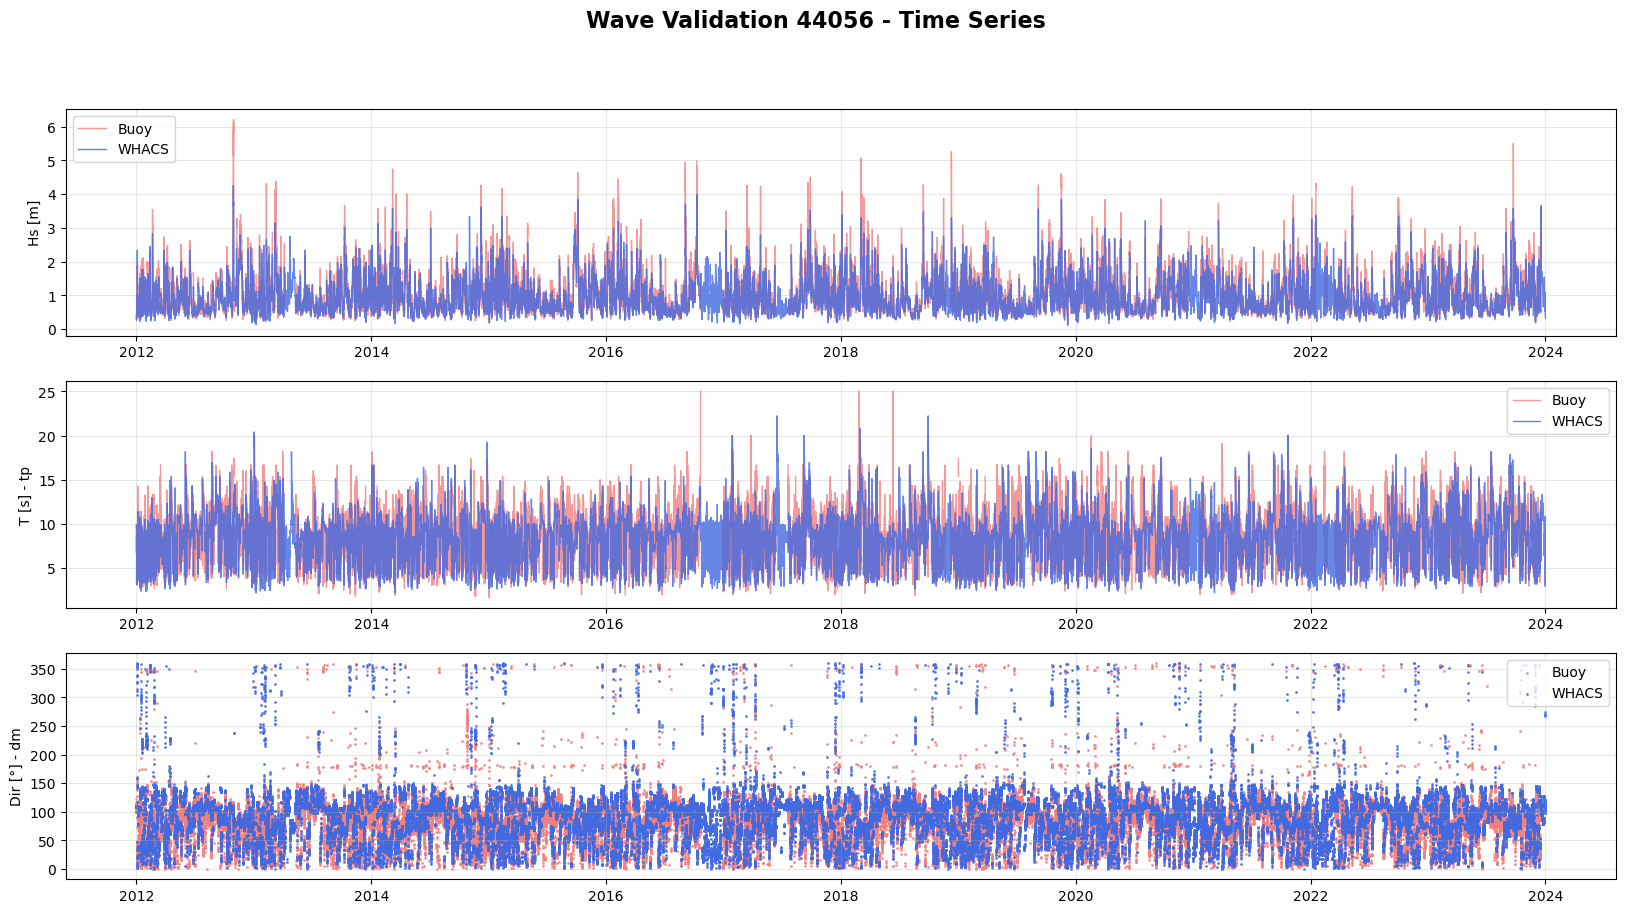

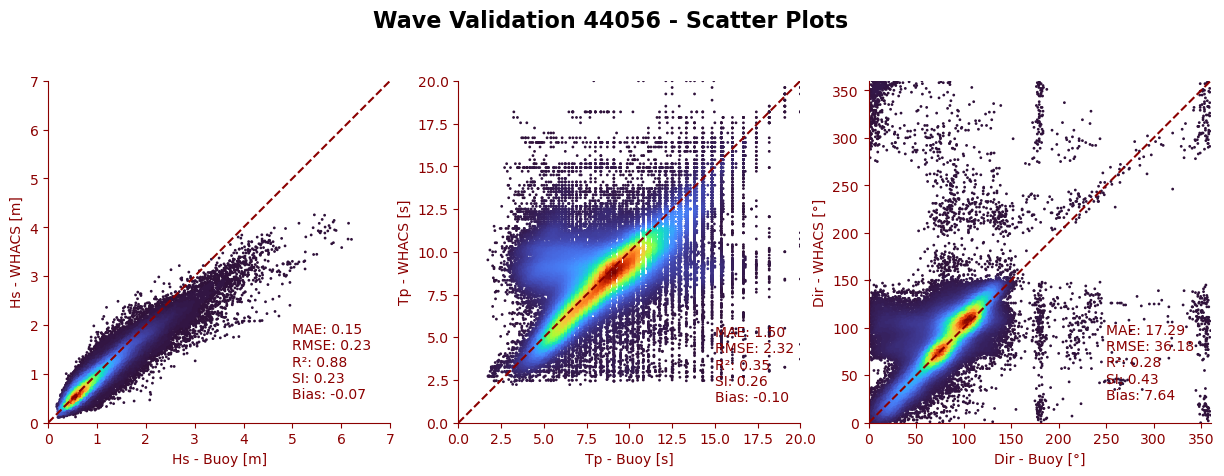

In [7]:
# Option 1: Use seapoint ID directly (recommended)
plot_whacs_vs_buoy(buoy_id="44056", whacs_seapoint= 1904402)